In [1]:
from analyzer import FeatureSelectionAnalyzer

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("../../../../data_raw/DataSet_V49 (2).xlsx")

In [4]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)"
]

In [6]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [7]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре'
]

In [8]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        pass 

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in category_cols:
    try:
        data[col] = data[col].fillna('missing')
        data[col] = data[col].astype(str) 
        data[col] = le.fit_transform(data[col])
        data[col] = data[col].astype('category')
    except KeyError: 
        pass

In [9]:
for col in category_cols:
    data[col] = data[col].fillna('missing').astype('str')
    data[col] = data[col].astype('category')

In [10]:
data = data[cols]

In [11]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [13]:
cat_features

['Sex',
 'Инфаркт миокарда в анамнезе (<3)',
 'Инфаркт миокарда в анамнезе (>3)',
 'Инфаркт миокарда со стентированием в анамнезе',
 'ОНМК (иш) в анамнезе',
 'ОНМК (гем) в анамнезе',
 'Стентирование в анамнезе',
 'Открытая перация на сердце в анамнезе',
 'АГ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'ХОБЛ (Новый столбец)',
 'Курит',
 'Экстракардиальная артериопатия',
 'Плохая мобильность',
 'Стенокардия (ИБ)',
 'Стенокардия форма(ИБ)',
 'Стенокардия ФК (ИБ)',
 'Стенокардия в диагнозе при поступлении',
 'ПИКС в диагнозе при поступлении',
 'Форма ФП',
 'ФП постоянная форма',
 'ФП при окс (до чкв)']

In [12]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [13]:
cat_features = []
for col in X_clean.columns:
    if X_clean[col].dtype.name == 'category': 
        cat_features.append(col)

In [14]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [15]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [16]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [18]:
list(X.select_dtypes(include=['category']).columns)

['Sex',
 'Инфаркт миокарда в анамнезе (<3)',
 'Инфаркт миокарда в анамнезе (>3)',
 'Инфаркт миокарда со стентированием в анамнезе',
 'ОНМК (иш) в анамнезе',
 'ОНМК (гем) в анамнезе',
 'Стентирование в анамнезе',
 'Открытая перация на сердце в анамнезе',
 'АГ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'ХОБЛ (Новый столбец)',
 'Курит',
 'Экстракардиальная артериопатия',
 'Плохая мобильность',
 'Стенокардия (ИБ)',
 'Стенокардия форма(ИБ)',
 'Стенокардия ФК (ИБ)',
 'Стенокардия в диагнозе при поступлении',
 'ПИКС в диагнозе при поступлении',
 'Форма ФП',
 'ФП постоянная форма',
 'ФП при окс (до чкв)']

In [17]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [18]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='balanced_accuracy')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  3%|▎         | 1/32 [00:04<02:07,  4.11s/it, balanced_accuracy=0.6874, Features=1]

Step 1: Добавлен признак 'Стенокардия_форма_ИБ', balanced_accuracy: 0.6874


  6%|▋         | 2/32 [00:08<02:09,  4.32s/it, balanced_accuracy=0.7165, Features=2]

Step 2: Добавлен признак 'Age', balanced_accuracy: 0.7165


...

Step 6: Добавлен признак 'Sex', balanced_accuracy: 0.7698


 22%|██▏       | 7/32 [00:31<01:56,  4.67s/it, balanced_accuracy=0.7720, Features=7]

Step 7: Добавлен признак 'ГБ_стадия', balanced_accuracy: 0.7720


 22%|██▏       | 7/32 [00:36<02:10,  5.20s/it, balanced_accuracy=0.7720, Features=7]

Step 8: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 7


In [19]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='balanced_accuracy')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  3%|▎         | 1/31 [00:21<10:43, 21.46s/it, balanced_accuracy=0.7714, Features=31]

Step 1: Удален признак 'ЖКБ', balanced_accuracy: 0.7714


  6%|▋         | 2/31 [00:43<10:24, 21.54s/it, balanced_accuracy=0.7739, Features=30]

Step 2: Удален признак 'Индекс_массы_тела', balanced_accuracy: 0.7739


  6%|▋         | 2/31 [01:03<15:22, 31.81s/it, balanced_accuracy=0.7739, Features=30]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 30



=== СРАВНЕНИЕ МЕТОДОВ ===


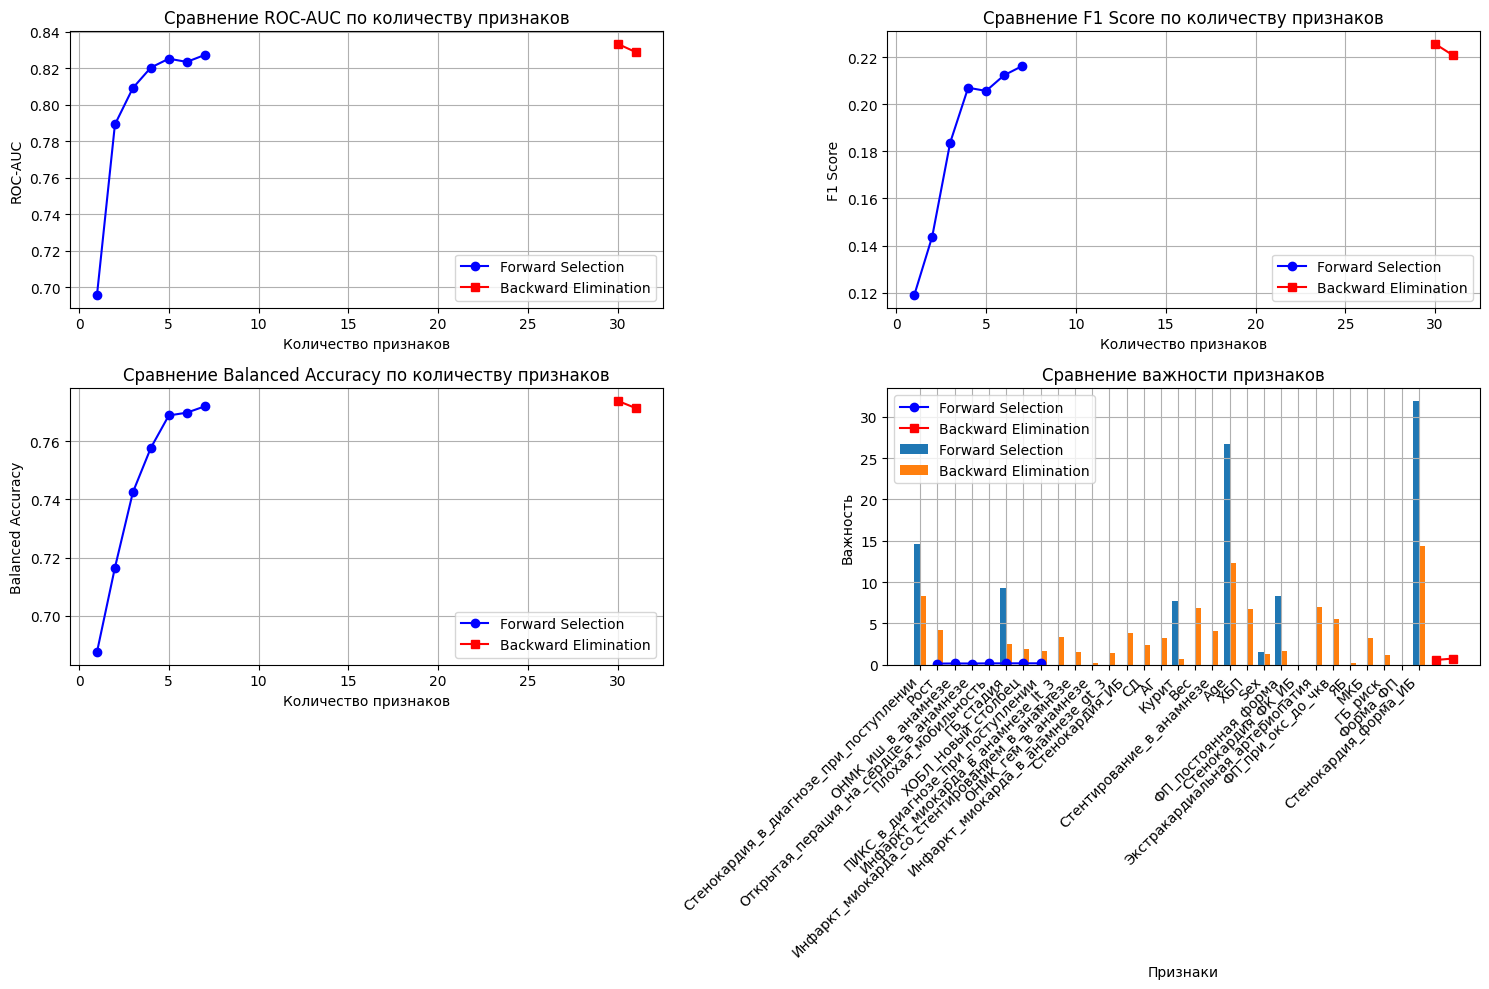

In [20]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [21]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 7 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.7720)
По Youden's J: 0.5078


In [22]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 30 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.7739)
По Youden's J: 0.5016



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


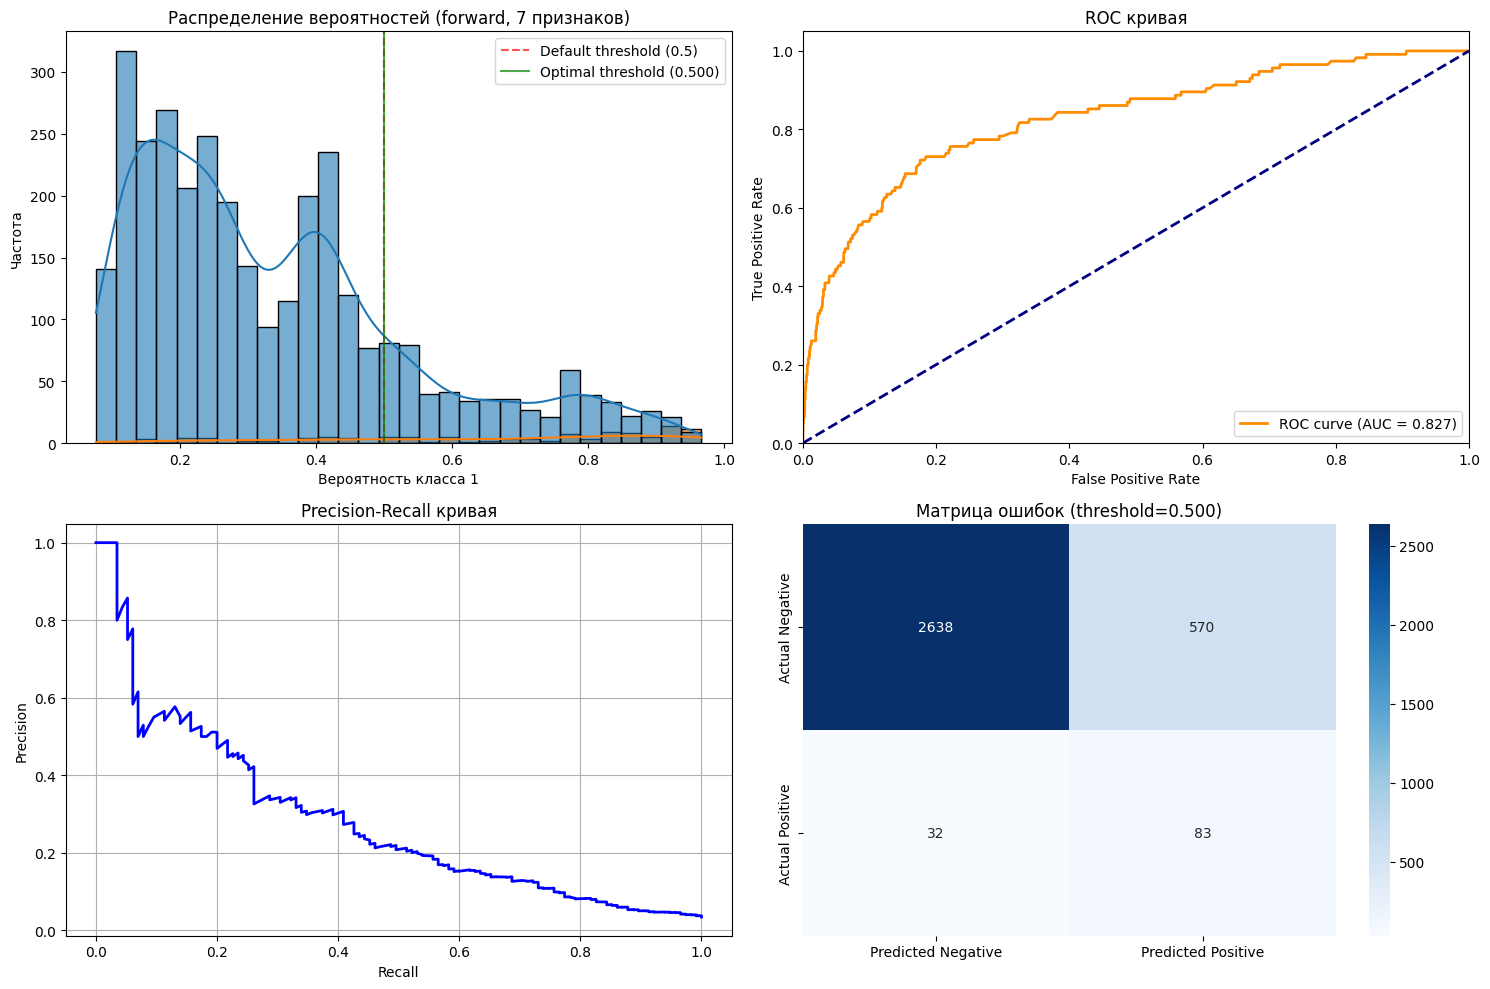

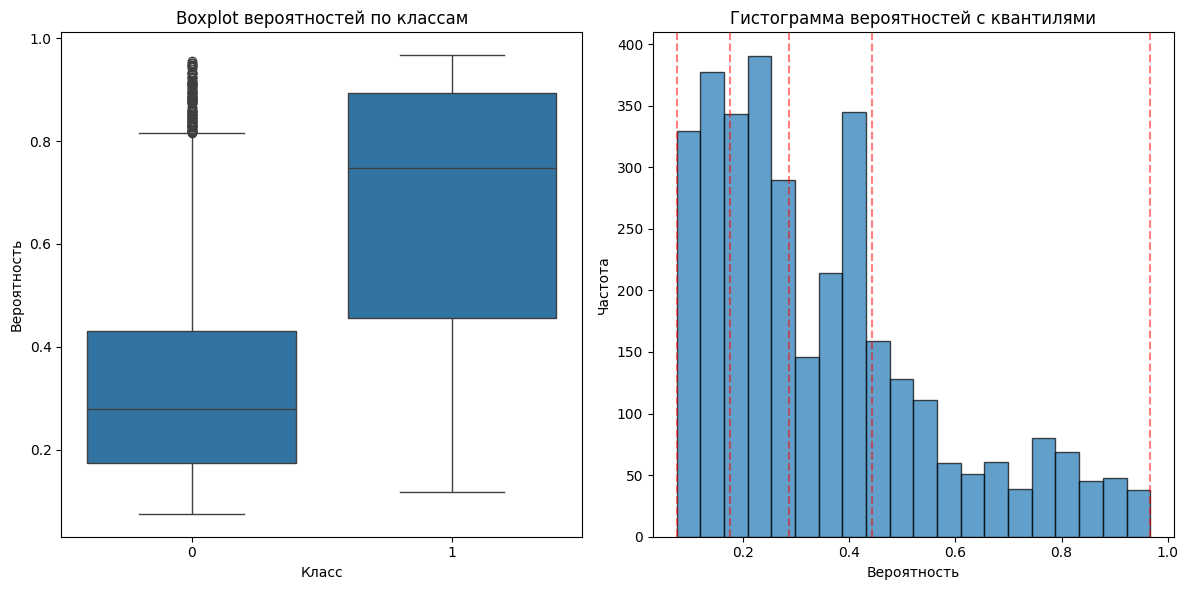

In [23]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


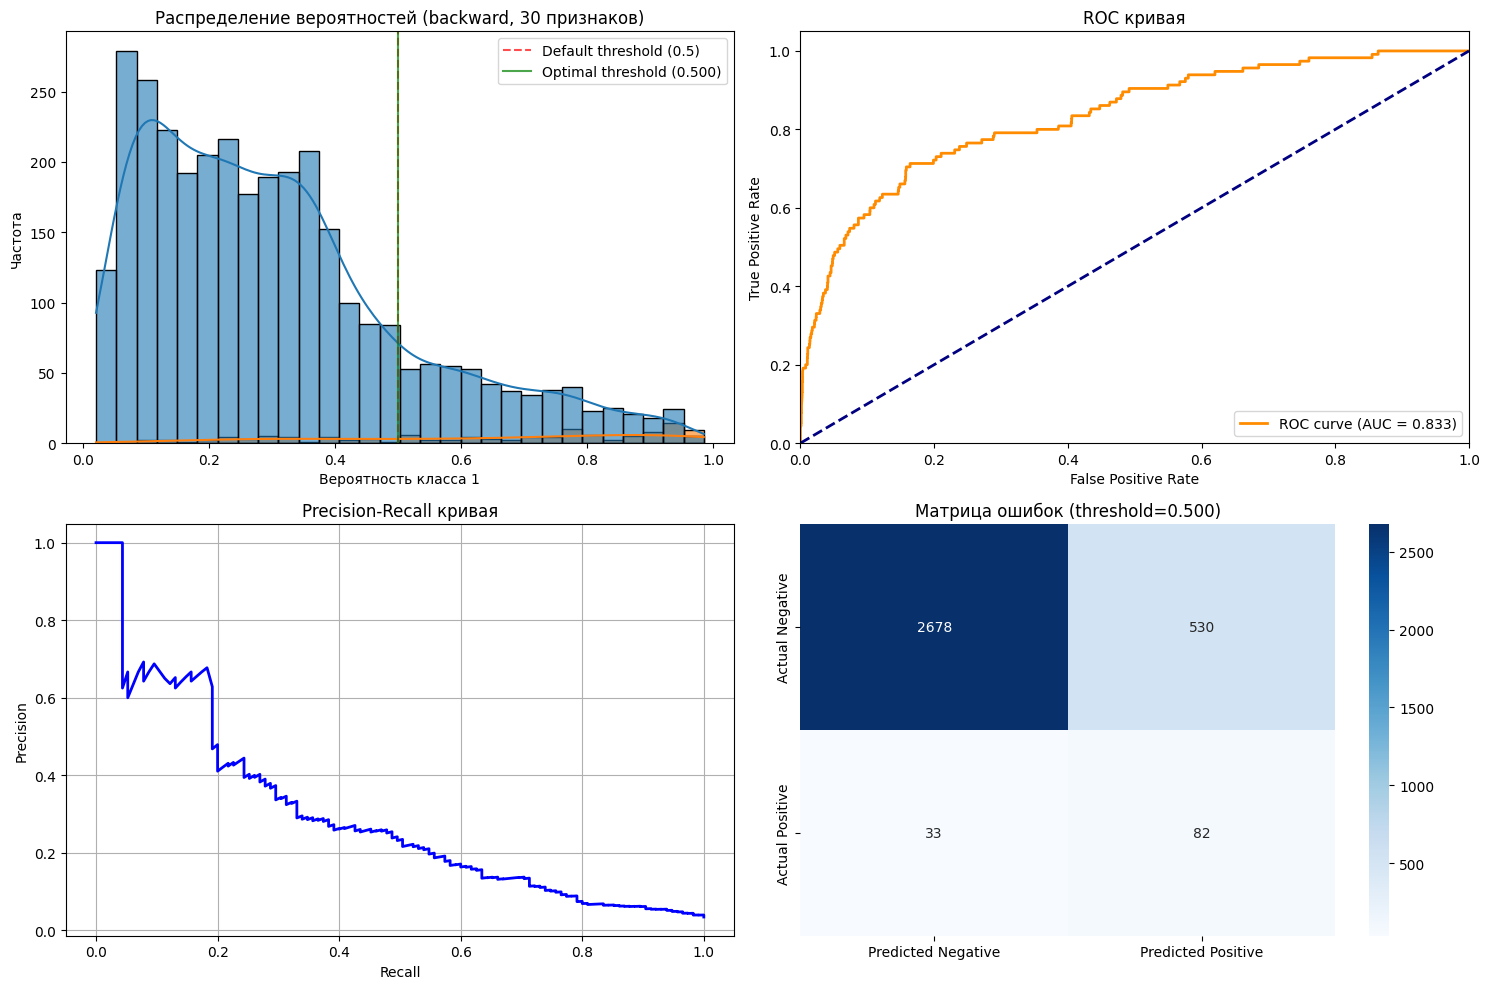

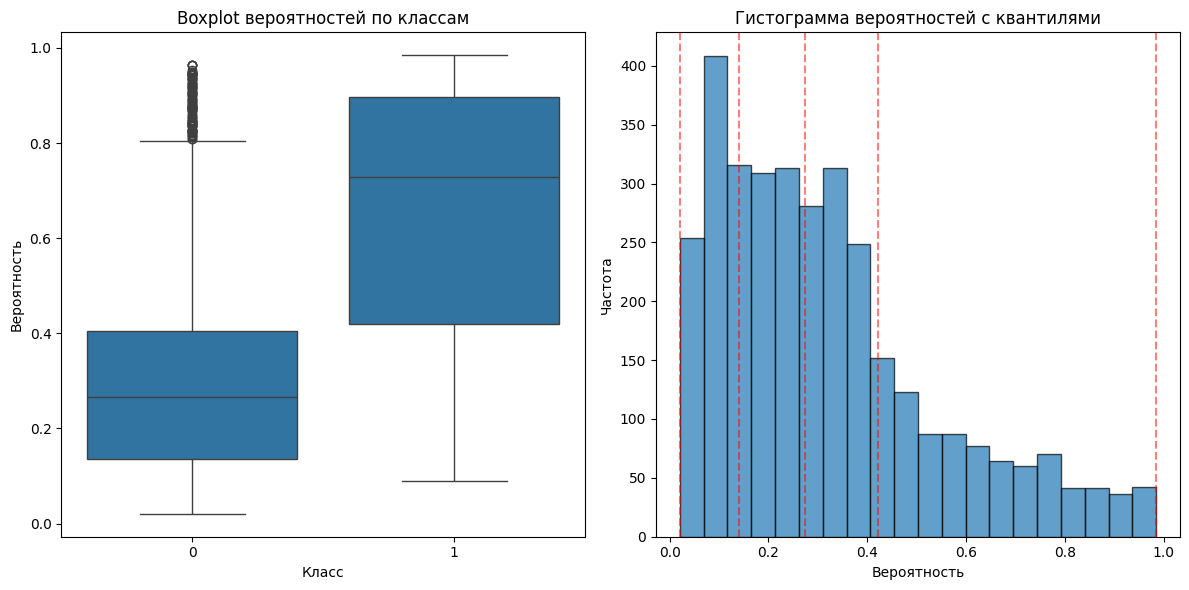

In [24]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [25]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 7
Лучшая f1: 0.2161
Признаки: ['Стенокардия_форма_ИБ', 'Age', 'Стенокардия_в_диагнозе_при_поступлении', 'ФП_постоянная_форма', 'Курит', 'Sex', 'ГБ_стадия']

Важность признаков:
  Стенокардия_форма_ИБ: 31.8556
  Age: 26.7092
  Стенокардия_в_диагнозе_при_поступлении: 14.5962
  ГБ_стадия: 9.3030
  ФП_постоянная_форма: 8.3167
  Курит: 7.6505
  Sex: 1.5689
=== Лучшие признаки (backward) ===
Количество признаков: 30
Лучшая f1: 0.2256
Признаки: ['Age', 'Sex', 'Рост', 'Вес', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Открытая_перация_на_сердце_в_анамнезе', 'ГБ_стадия', 'ГБ_риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ХОБЛ_Новый_столбец', 'Курит', 'Экстракардиальная_артериопатия', 'Плохая_мобильность', 'Стенокардия_ИБ', 'Стенокардия_форма_ИБ', 'Стенока

In [26]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.8272 с 7 признаками
Лучший ROC AUC (Backward): 0.8333 с 30 признаками
Оптимальный порог для бинарной классификации: 0.5000


-----------------

In [27]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [28]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='balanced_accuracy')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  3%|▎         | 1/32 [03:06<1:36:15, 186.29s/it, balanced_accuracy=0.6874, Features=1]

Step 1: Добавлен признак 'Стенокардия_форма_ИБ', balanced_accuracy: 0.6874


  6%|▋         | 2/32 [07:26<1:55:00, 230.02s/it, balanced_accuracy=0.7283, Features=2]

Step 2: Добавлен признак 'Age', balanced_accuracy: 0.7283


...

Step 8: Добавлен признак 'Курит', balanced_accuracy: 0.7691


 28%|██▊       | 9/32 [35:35<1:27:46, 228.98s/it, balanced_accuracy=0.7736, Features=9]

Step 9: Добавлен признак 'ХБП', balanced_accuracy: 0.7736


 28%|██▊       | 9/32 [39:00<1:39:42, 260.09s/it, balanced_accuracy=0.7736, Features=9]

Step 10: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 9


In [29]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='balanced_accuracy')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  3%|▎         | 1/31 [04:45<2:22:50, 285.67s/it, balanced_accuracy=0.7576, Features=31]

Step 1: Удален признак 'ХОБЛ_Новый_столбец', balanced_accuracy: 0.7576


  6%|▋         | 2/31 [09:22<2:15:38, 280.65s/it, balanced_accuracy=0.7663, Features=30]

Step 2: Удален признак 'ФП_постоянная_форма', balanced_accuracy: 0.7663


  6%|▋         | 2/31 [13:50<3:20:45, 415.37s/it, balanced_accuracy=0.7663, Features=30]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 30



=== СРАВНЕНИЕ МЕТОДОВ ===


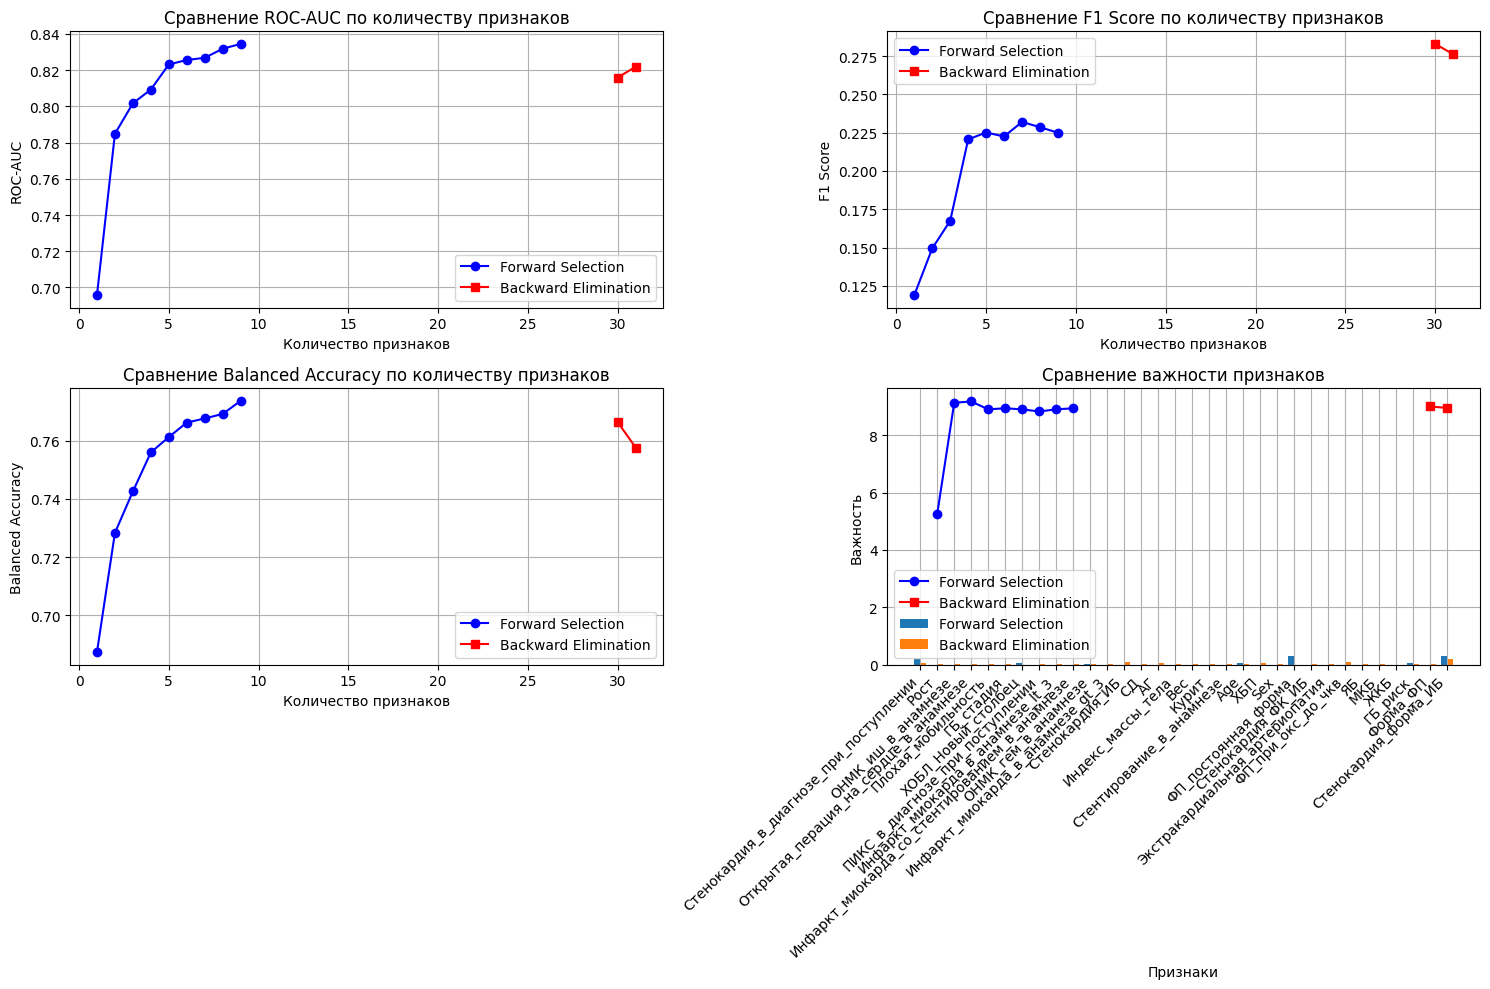

In [30]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [31]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 9 признаков) ===
По Balanced Accuracy score: 0.5300 (F1=0.7789)
По Youden's J: 0.5311


In [32]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 30 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.7663)
По Youden's J: 0.5052



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


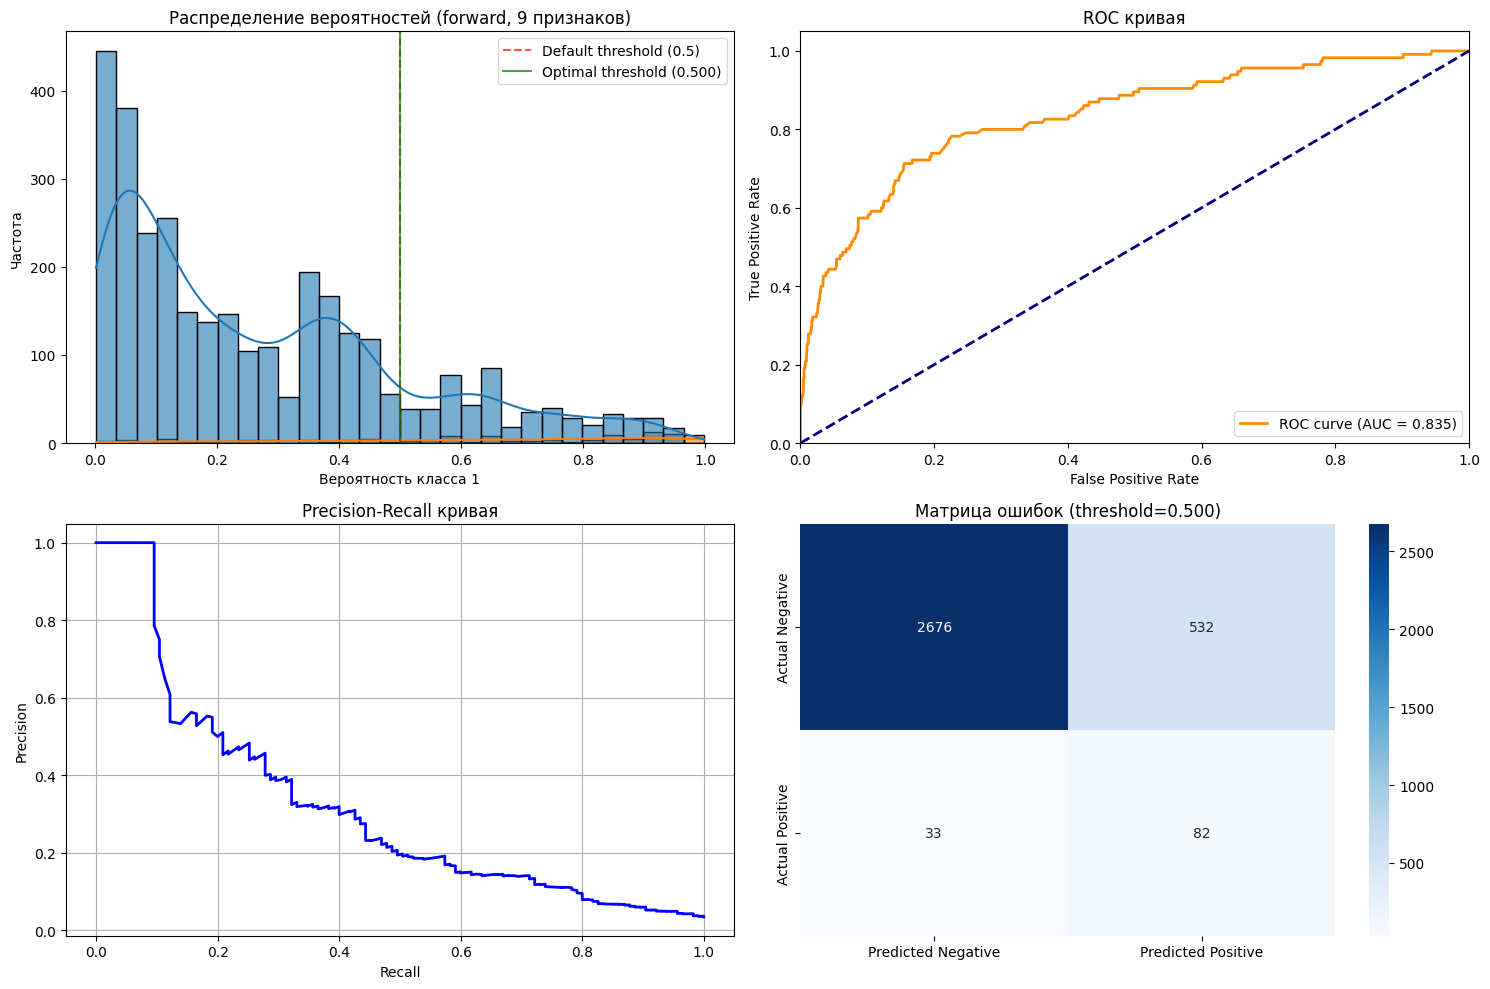

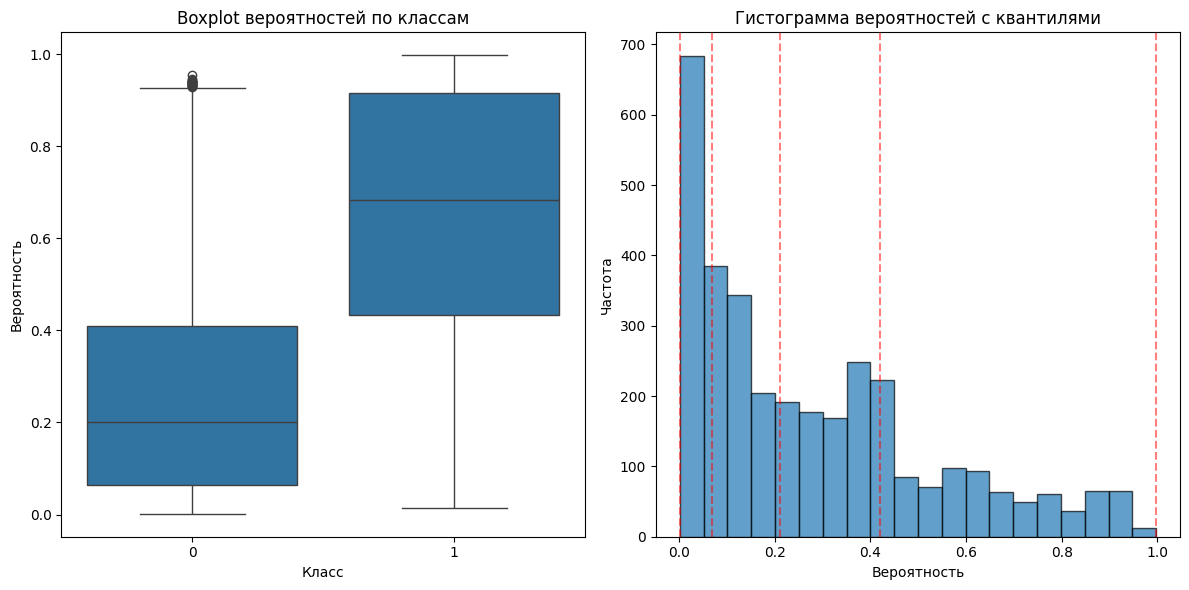

In [33]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


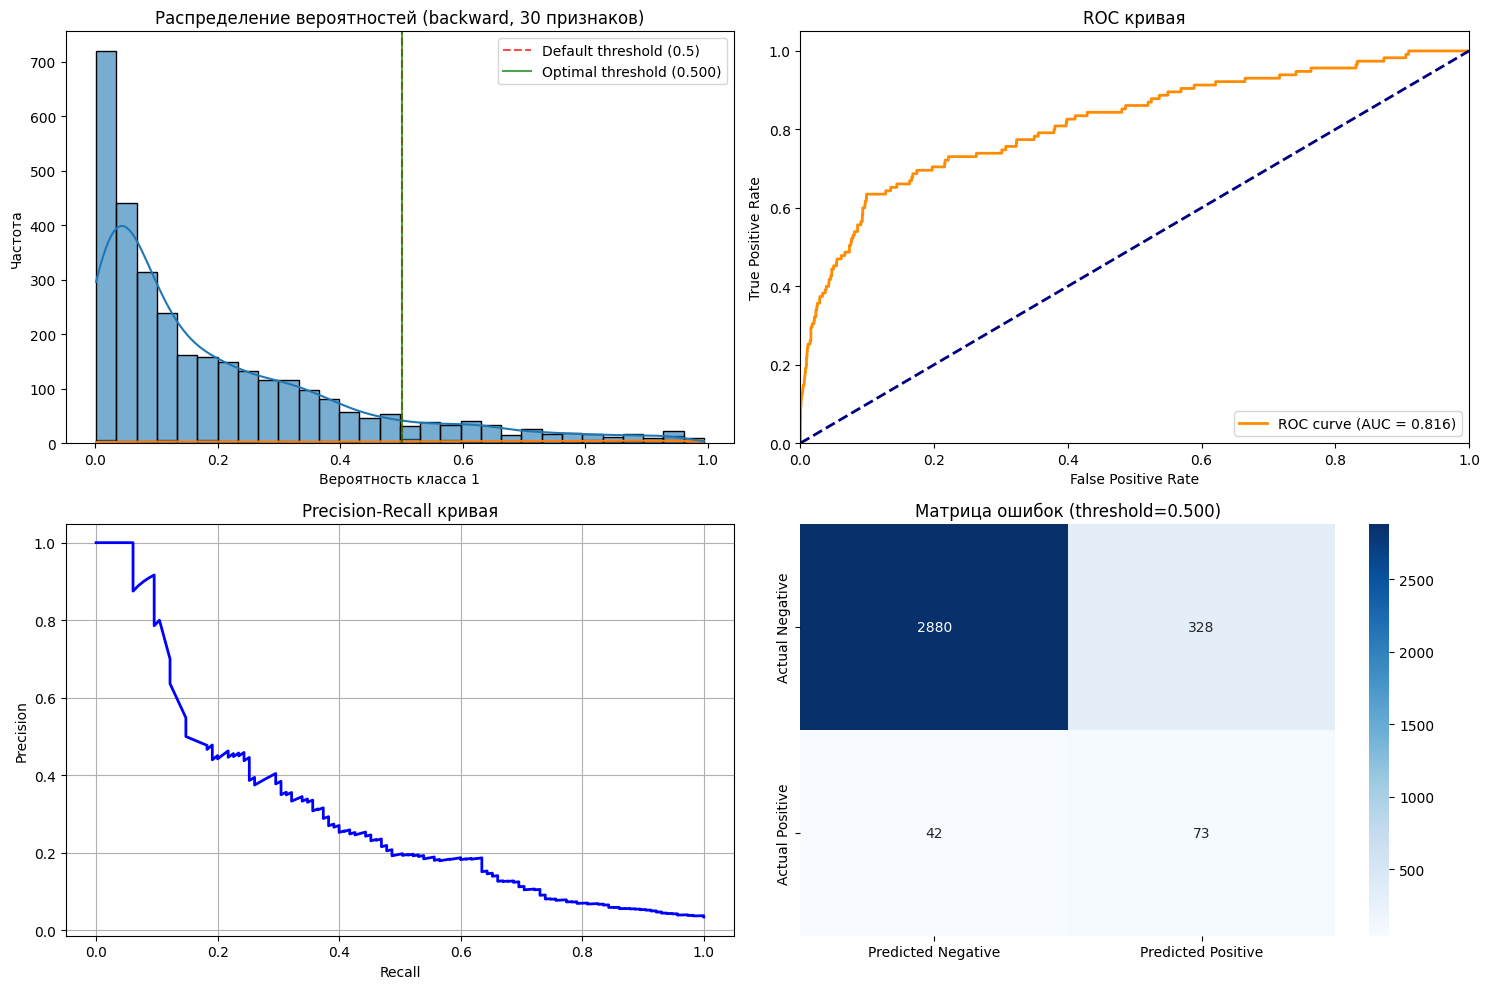

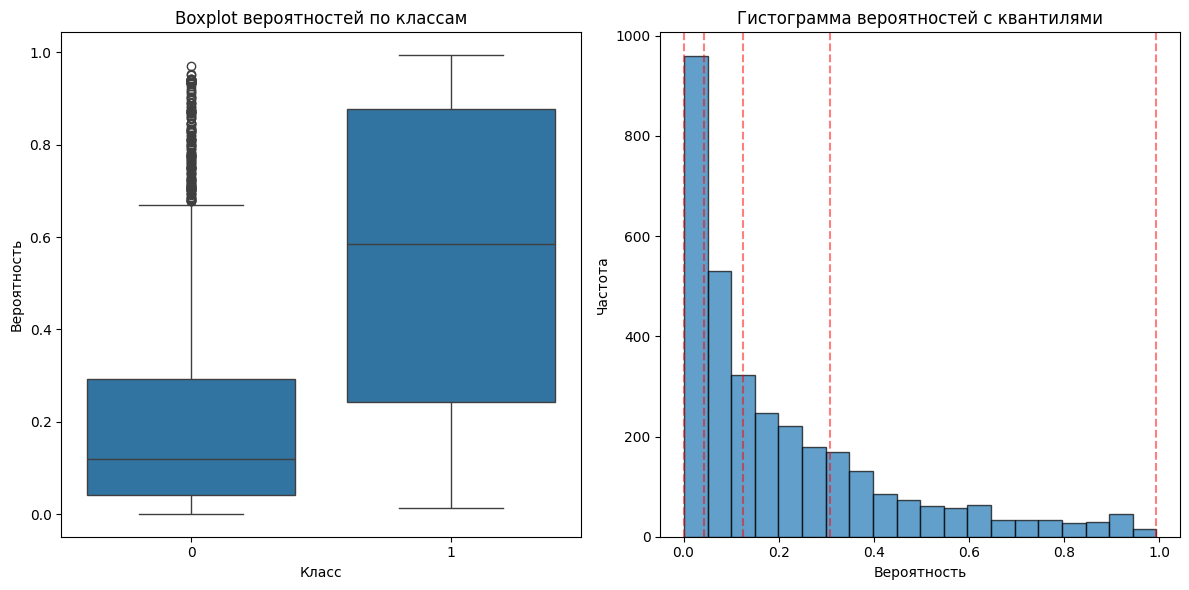

In [34]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [35]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 7
Лучшая f1: 0.2320
Признаки: ['Стенокардия_форма_ИБ', 'Age', 'Стенокардия_в_диагнозе_при_поступлении', 'ФП_постоянная_форма', 'ГБ_риск', 'ХОБЛ_Новый_столбец', 'ОНМК_гем_в_анамнезе']

Важность признаков:
  Стенокардия_форма_ИБ: 0.2953
  ФП_постоянная_форма: 0.2948
  Стенокардия_в_диагнозе_при_поступлении: 0.2020
  Age: 0.0635
  ХОБЛ_Новый_столбец: 0.0567
  ГБ_риск: 0.0471
  ОНМК_гем_в_анамнезе: 0.0405
=== Лучшие признаки (backward) ===
Количество признаков: 30
Лучшая f1: 0.2829
Признаки: ['Age', 'Sex', 'Рост', 'Вес', 'Индекс_массы_тела', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Открытая_перация_на_сердце_в_анамнезе', 'ГБ_стадия', 'ГБ_риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Курит', 'Экстракардиальная_артериопатия', 'Плохая_мобильн

In [36]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.8268 с 7 признаками
Лучший ROC AUC (Backward): 0.8159 с 30 признаками
Оптимальный порог для бинарной классификации: 0.5000


In [37]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [38]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='balanced_accuracy')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  3%|▎         | 1/32 [02:40<1:22:53, 160.44s/it, balanced_accuracy=0.6874, Features=1]

Step 1: Добавлен признак 'Стенокардия_форма_ИБ', balanced_accuracy: 0.6874


  6%|▋         | 2/32 [07:45<2:02:53, 245.79s/it, balanced_accuracy=0.7305, Features=2]

Step 2: Добавлен признак 'Age', balanced_accuracy: 0.7305


...

Step 4: Добавлен признак 'ФП_при_окс_до_чкв', balanced_accuracy: 0.7662


 16%|█▌        | 5/32 [30:56<3:08:04, 417.95s/it, balanced_accuracy=0.7707, Features=5]

Step 5: Добавлен признак 'ФП_постоянная_форма', balanced_accuracy: 0.7707


 16%|█▌        | 5/32 [38:52<3:29:54, 466.47s/it, balanced_accuracy=0.7707, Features=5]

Step 6: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 5


In [39]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='balanced_accuracy')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  3%|▎         | 1/31 [10:40<5:20:27, 640.93s/it, balanced_accuracy=0.7625, Features=31]

Step 1: Удален признак 'Стентирование_в_анамнезе', balanced_accuracy: 0.7625


  6%|▋         | 2/31 [20:55<5:02:16, 625.40s/it, balanced_accuracy=0.7683, Features=30]

Step 2: Удален признак 'Стенокардия_ИБ', balanced_accuracy: 0.7683


  6%|▋         | 2/31 [30:49<7:26:54, 924.62s/it, balanced_accuracy=0.7683, Features=30]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 30



=== СРАВНЕНИЕ МЕТОДОВ ===


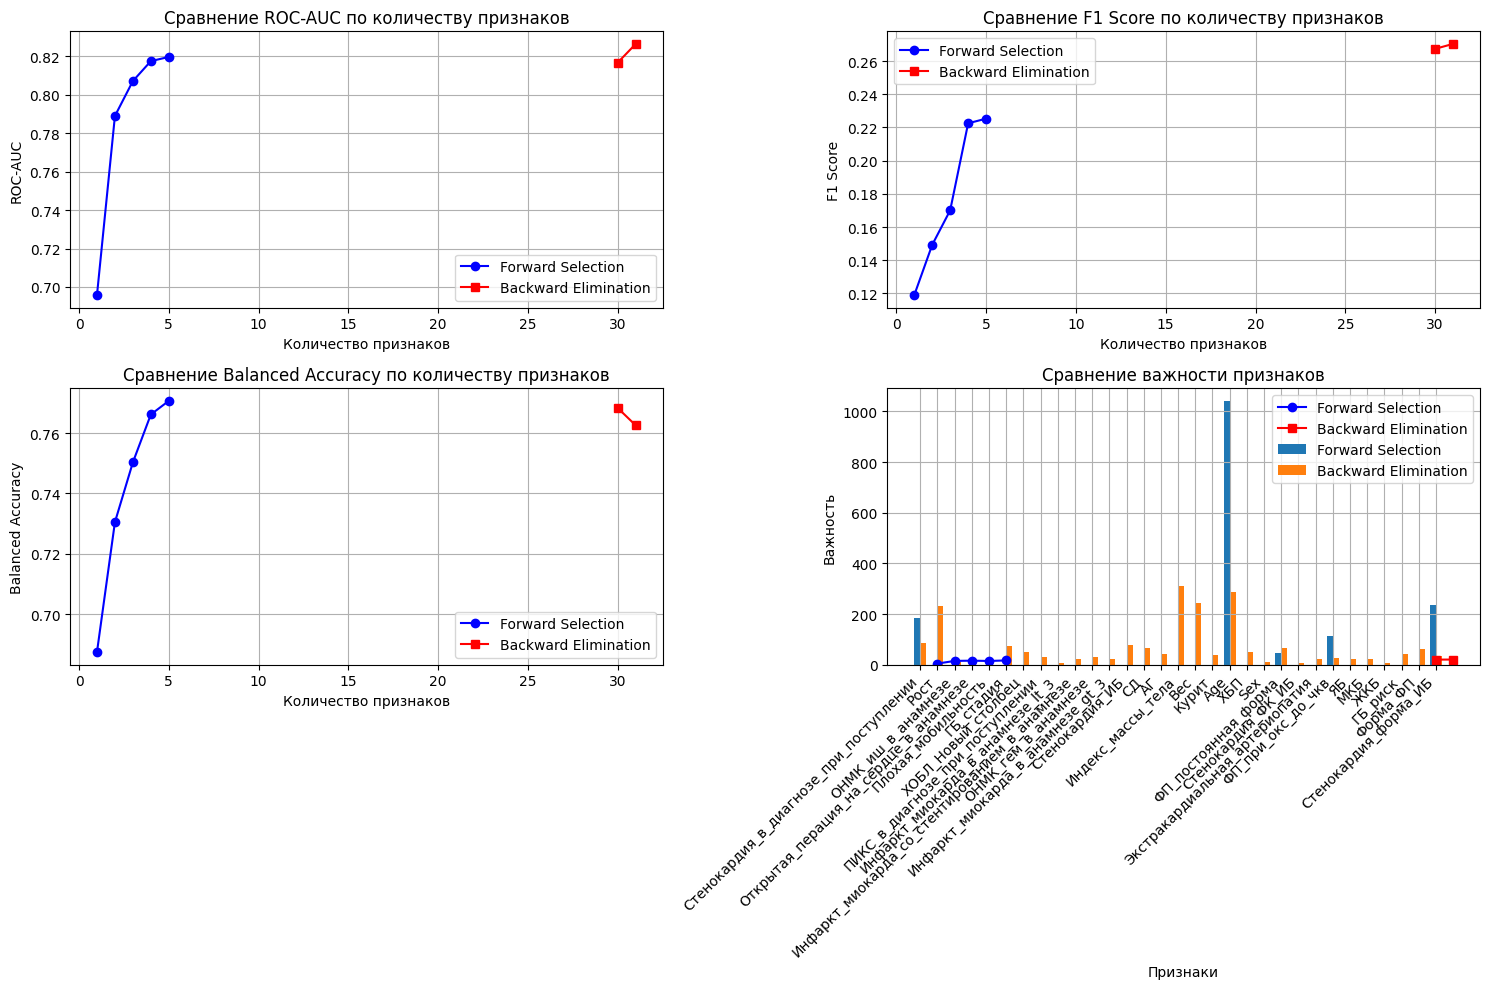

In [40]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [41]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 5 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.7707)
По Youden's J: 0.4583


In [42]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 30 признаков) ===
По Balanced Accuracy score: 0.3900 (F1=0.7742)
По Youden's J: 0.3989



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


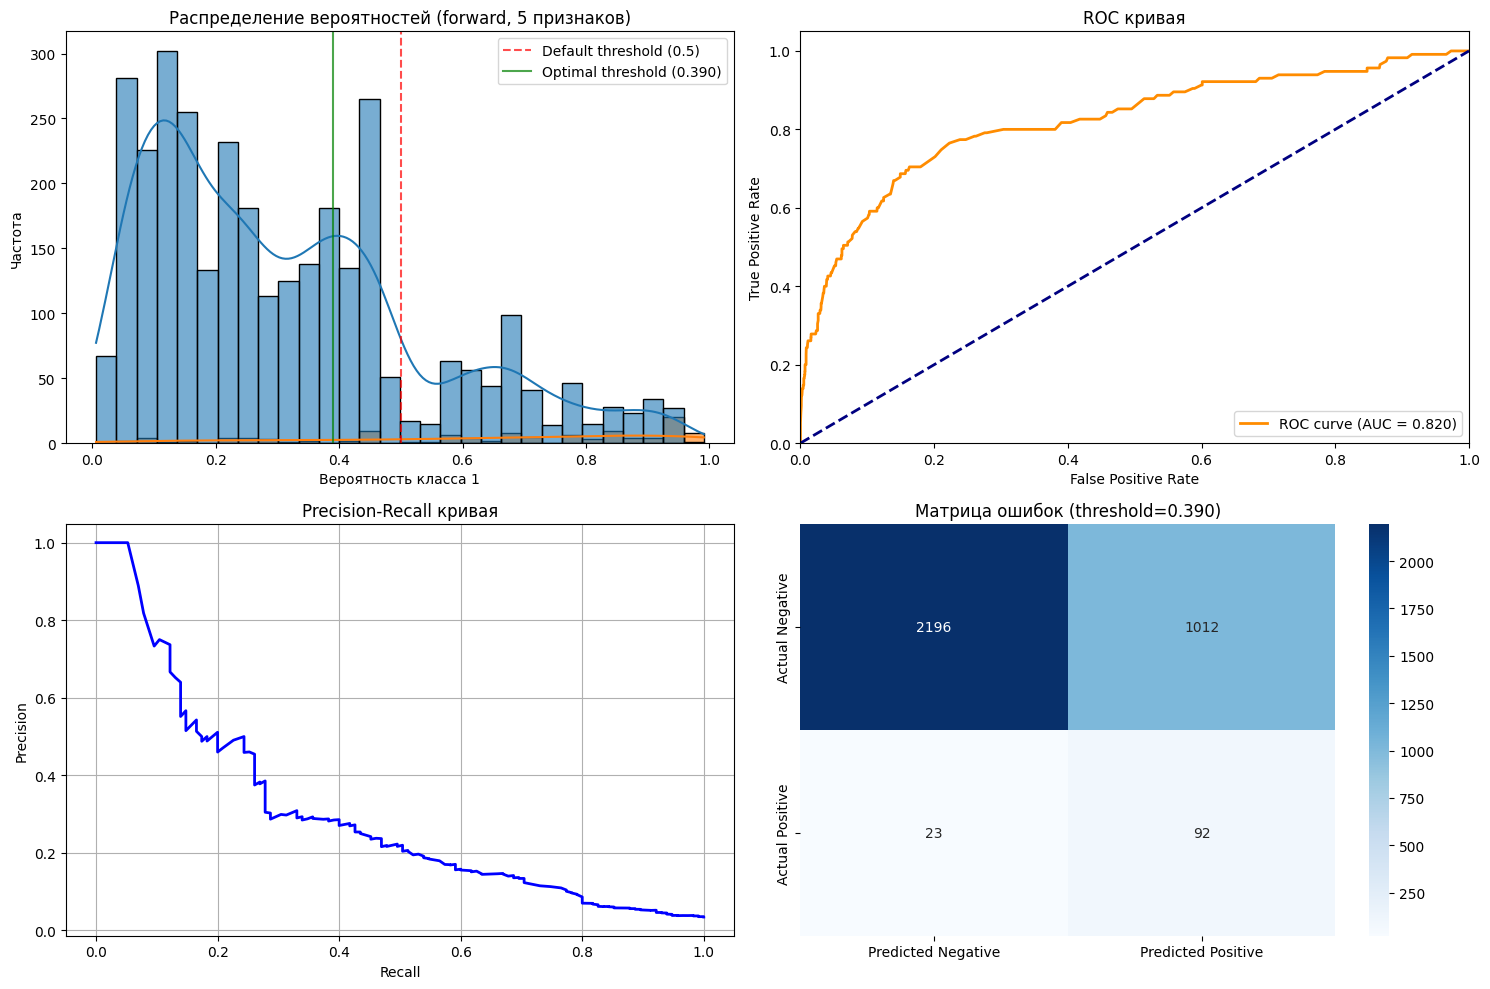

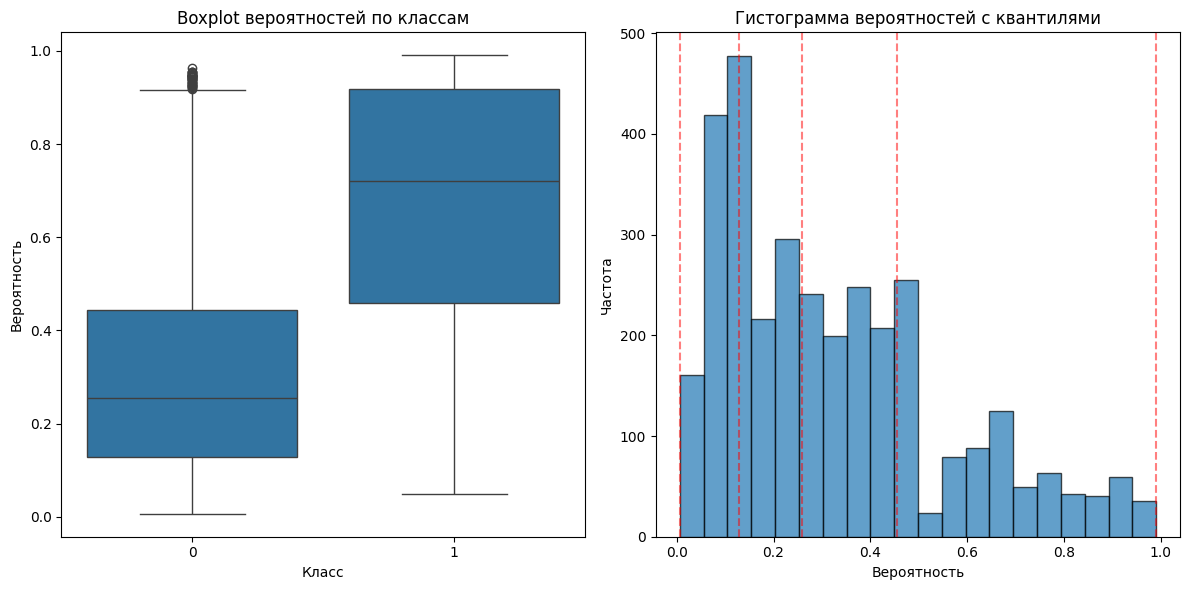

In [43]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


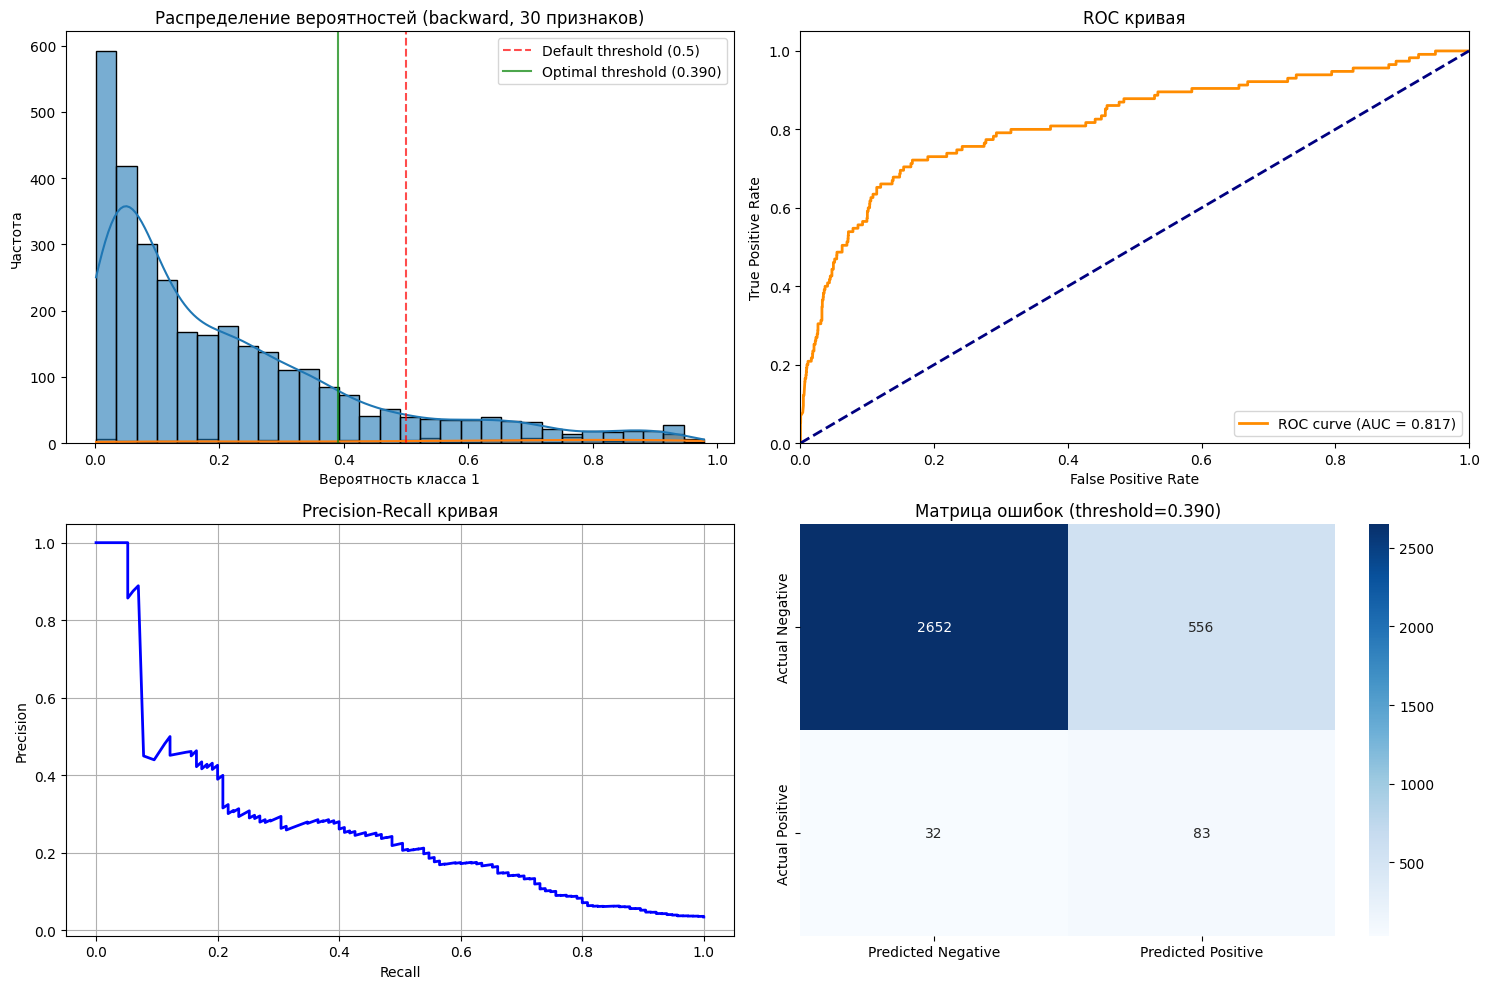

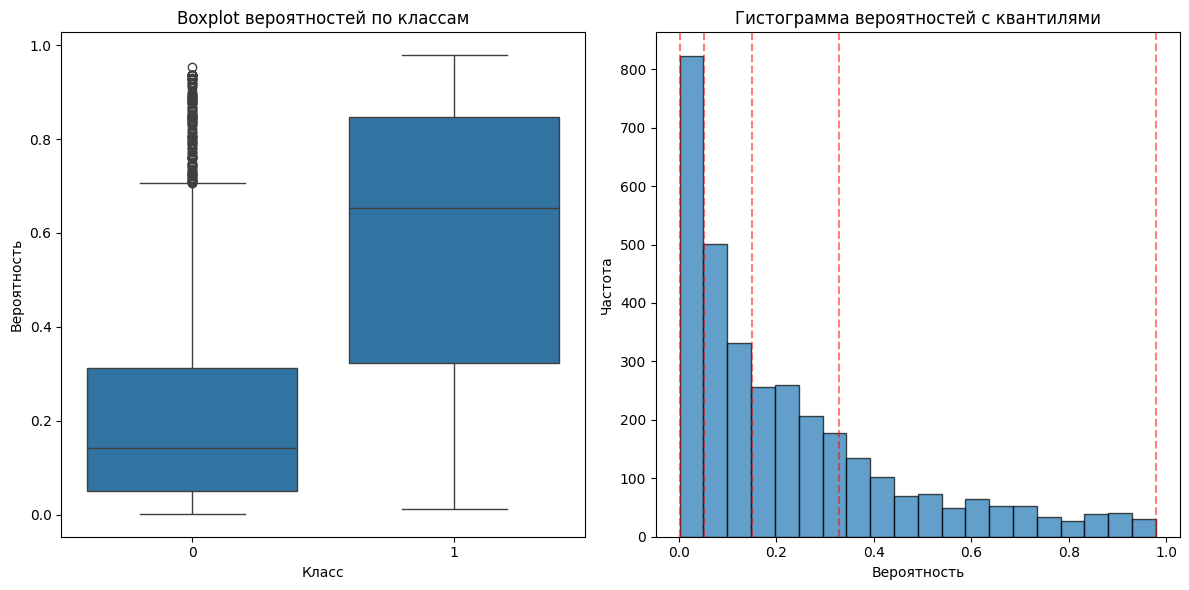

In [44]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [45]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 5
Лучшая f1: 0.2253
Признаки: ['Стенокардия_форма_ИБ', 'Age', 'Стенокардия_в_диагнозе_при_поступлении', 'ФП_при_окс_до_чкв', 'ФП_постоянная_форма']

Важность признаков:
  Age: 1039.0000
  Стенокардия_форма_ИБ: 234.0000
  Стенокардия_в_диагнозе_при_поступлении: 186.0000
  ФП_при_окс_до_чкв: 112.0000
  ФП_постоянная_форма: 46.0000
=== Лучшие признаки (backward) ===
Количество признаков: 31
Лучшая f1: 0.2704
Признаки: ['Age', 'Sex', 'Рост', 'Вес', 'Индекс_массы_тела', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Открытая_перация_на_сердце_в_анамнезе', 'ГБ_стадия', 'ГБ_риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'ХОБЛ_Новый_столбец', 'Курит', 'Экстракардиальная_артериопатия', 'Плохая_мобильность', 'Стенокардия_ИБ', 'Стенокардия_форма_ИБ', 'Стенокардия_ФК_ИБ', 'Стенокард

In [46]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.8197 с 5 признаками
Лучший ROC AUC (Backward): 0.8265 с 31 признаками
Оптимальный порог для бинарной классификации: 0.3900


In [ ]:
1